In [2]:
!git clone https://github.com/syed-rayyanadil/pointnet-foldingnet-completion.git

fatal: destination path 'pointnet-foldingnet-completion' already exists and is not an empty directory.


In [3]:
%cd pointnet-foldingnet-completion

/content/pointnet-foldingnet-completion


In [4]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.2 MB/s eta 0:00:00


In [5]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0)}")

GPU available: True
Device: Tesla T4


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!cp "/content/drive/MyDrive/Point Cloud Completion with Uncertainty Estimation/data/ModelNet40.zip" /content/
!unzip -q /content/ModelNet40.zip -d /content/pointnet-foldingnet-completion/data/

In [9]:
import os
for cat in ["chair", "table", "airplane"]:
    path = f"/content/pointnet-foldingnet-completion/data/ModelNet40/{cat}/train"
    count = len(os.listdir(path))
    print(f"{cat}: {count} files")

chair: 889 files
table: 392 files
airplane: 626 files


In [10]:
!python train.py \
    --categories chair table airplane \
    --epochs 50 \
    --batch_size 16 \
    --device cuda | tee training_log.txt

Using device: cuda
Dataset: [chair, table, airplane] - 1907 samples (119 batches/epoch)
Model: pointnet encoder - 941,699 parameters

Starting training for 50 epochs...

  Epoch [1/50] Batch [10/119] Loss: 0.672457
  Epoch [1/50] Batch [20/119] Loss: 0.737496
  Epoch [1/50] Batch [30/119] Loss: 0.598432
  Epoch [1/50] Batch [40/119] Loss: 0.725067
  Epoch [1/50] Batch [50/119] Loss: 0.703645
  Epoch [1/50] Batch [60/119] Loss: 0.649265
  Epoch [1/50] Batch [70/119] Loss: 0.559798
  Epoch [1/50] Batch [80/119] Loss: 0.567741
  Epoch [1/50] Batch [90/119] Loss: 0.614203
  Epoch [1/50] Batch [100/119] Loss: 0.587227
  Epoch [1/50] Batch [110/119] Loss: 0.617655
  Epoch [1/50] Batch [119/119] Loss: 0.560218
Epoch 1/50 complete | Avg Loss: 0.627934 | Time: 187.8s
  Saved best model checkpoint to checkpoints/best_model.pth

  Epoch [2/50] Batch [10/119] Loss: 0.653398
  Epoch [2/50] Batch [20/119] Loss: 0.447925
  Epoch [2/50] Batch [30/119] Loss: 0.610755
  Epoch [2/50] Batch [40/119] Loss:

In [15]:
import shutil
from google.colab import files

# Zip the entire checkpoints folder into one file
shutil.make_archive(
    "/content/checkpoints_backup",  # output zip name
    "zip",
    "/content/pointnet-foldingnet-completion/checkpoints"
)

# Download the single zip
files.download("/content/checkpoints_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import shutil
shutil.copytree(
    "/content/pointnet-foldingnet-completion/checkpoints",
    "/content/drive/MyDrive/Point Cloud Completion with Uncertainty Estimation/checkpoints"
)
print("Checkpoints saved to Drive!")

Checkpoints saved to Drive!


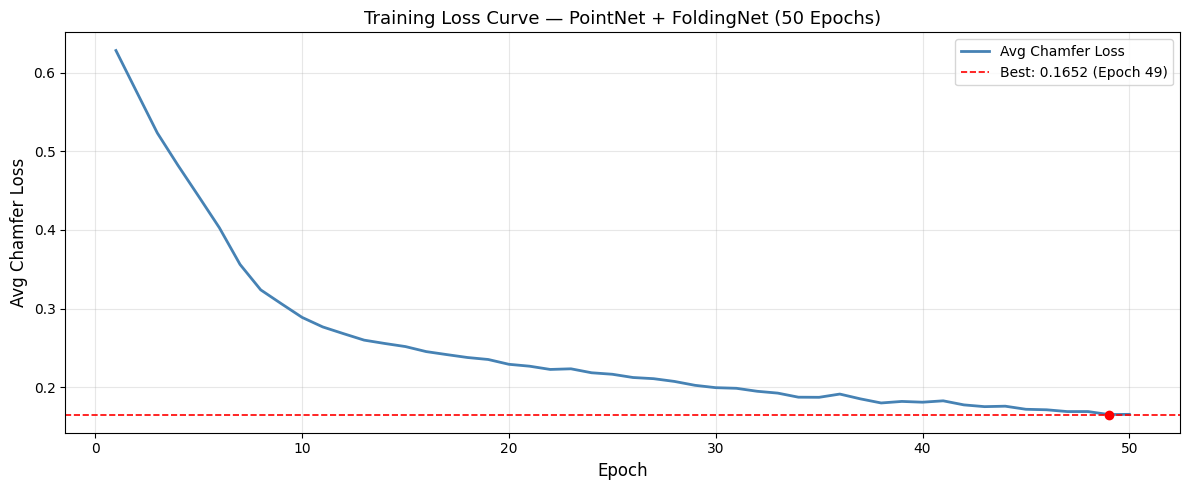

Best Chamfer Loss: 0.165236 at Epoch 49


In [16]:
import re, matplotlib.pyplot as plt

with open("training_log.txt") as f:
    lines = f.readlines()

losses = [float(re.search(r"Avg Loss: ([0-9.]+)", l).group(1))
          for l in lines if "Avg Loss:" in l]

plt.figure(figsize=(12, 5))
plt.plot(losses, linewidth=2, color='steelblue')
plt.xlabel("Epoch"); plt.ylabel("Avg Chamfer Loss")
plt.title("Training Loss Curve"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("loss_curve.png", dpi=150); plt.show()